# Module 11 - Sampling and decoding

Use this notebook after Module 11 sampling tests are passing. It automatically loads the strongest model artifact you saved from Module 10, in this order:

1. `ShakespeareLM-1M`
2. `StoryLM-5M` / `StoryLM-Small`
3. `StoryLM-10M`
4. `StoryLM-30M` / `StoryLM`
5. `TinyLLM-30M` / `TinyLLM`
6. `TinyLLM-100M`

The point is to develop sampling intuition against the best model you personally trained. If you only saved `ShakespeareLM-1M`, the notebook still works; if you later save a stronger artifact, re-run the load cell and the exercises will use it.

1. Read the lesson page (`docs/modules/11-sampling.md`).
2. Open this notebook with `.venv/bin/python scripts/open_notebook.py 11`.
3. Implement `g2c/sampling/` until the tests pass.
4. Run the cells below and answer the inline prompts.
5. When you're ready, ask a coding agent to grade your notebook.

Partial work is fine. Blank `Answer: ""` strings are skipped, not counted wrong. If you'd like a hint instead of a grade, write the request inline in the answer string and the agent will tutor first.

In [1]:
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

import g2c
from g2c.artifacts import (
    available_model_artifacts,
    baselm_artifact_exists,
    load_best_model_artifact,
    load_model_artifact_with_tokenizer,
)
from g2c.notebook_extras.sampling import (
    decode_ids,
    default_sampling_prompt,
    encode_prompt,
    eos_id,
    next_token_rows,
    print_sample,
    sample_ids,
    sample_text,
    type_token_ratio,
)
from g2c.sampling import (
    apply_temperature,
    top_p_filter,
)

repo_root = Path(g2c.__file__).resolve().parents[1]
print("repo root:", repo_root)
print("MPS available:", torch.backends.mps.is_available())

repo root: /Users/colkitt/sith/toys/courses/g2c
MPS available: True


## Before the exercises

The notebook is intentionally downstream of the implementation work. The first cell below checks `tests/test_sampling.py`; if it fails, use the failing test names as your implementation guide before continuing.

In [2]:
"Run from the terminal if this fails: .venv/bin/python -m pytest tests/test_sampling.py -x"
"Question: Which sampling test was hardest to make pass, and what bug did it catch?"
"Answer: "

'Answer: '

In [3]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_sampling.py"],
    cwd=repo_root,
    text=True,
    capture_output=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
assert result.returncode == 0, "Module 11 sampling tests are not passing yet."
print("Module 11 sampling tests passed.")

............................................                             [100%]
44 passed in 0.57s

Module 11 sampling tests passed.


## Load a model artifact

By default this cell loads the strongest self-trained reusable artifact it can find. Set `MODEL_ARTIFACT_NAME` to a specific artifact name, such as `"StoryLM-Small"`, `"TinyLLM"`, or `"BaseLM"`, when you want to compare a specific model. Run `./baselm.sh` before using `"BaseLM"`.

In [5]:
MODEL_ARTIFACT_NAME: str | None = None
# MODEL_ARTIFACT_NAME = "StoryLM-Small"  # Override to force a specific artifact.
MODEL_ARTIFACT_NAME = "BaseLM"         # External pretrained base-model path.
BASELM_INFERENCE_DTYPE = "float16"      # Module 11 only: lower-memory BaseLM inference.

available = available_model_artifacts(repo_root=repo_root)
if available:
    print("available model artifacts:")
    for artifact in available:
        print(f"  rank {artifact.rank:>2}: {artifact.display_name:<14} -> {artifact.name}")
else:
    print("No model artifacts found yet under artifacts/models/.")
    print("Run Module 10 and save at least one artifact, or run ./baselm.sh and set MODEL_ARTIFACT_NAME = 'BaseLM'.")
if baselm_artifact_exists(repo_root=repo_root):
    print("external fallback: BaseLM -> artifacts/models/BaseLM")

if MODEL_ARTIFACT_NAME is None:
    model_artifact = load_best_model_artifact(
        repo_root=repo_root,
        device="auto",
        required=False,
    )
else:
    model_artifact = load_model_artifact_with_tokenizer(
        MODEL_ARTIFACT_NAME,
        repo_root=repo_root,
        device="auto",
        torch_dtype=BASELM_INFERENCE_DTYPE if MODEL_ARTIFACT_NAME == "BaseLM" else None,
    )

if model_artifact is None:
    model = None
    tokenizer = None
else:
    model = model_artifact.model
    tokenizer = model_artifact.tokenizer
    manifest = model_artifact.manifest
    print("\nloaded:", model_artifact.display_name, f"({model_artifact.name})")
    print("source:", manifest.get("source"))
    print("tokenizer:", manifest.get("tokenizer_artifact"))
    print("vocab size:", model.vocab_size)
    print("max seq len:", model.max_seq_len)
    print("parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
    print("device:", model.device)

available model artifacts:
  rank 10: ShakespeareLM  -> ShakespeareLM-1M
  rank 20: StoryLM 5M     -> StoryLM-Small
  rank 35: StoryLM 30M    -> StoryLM
  rank 40: TinyLLM 30M    -> TinyLLM
external fallback: BaseLM -> artifacts/models/BaseLM


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`



loaded: BaseLM (BaseLM)
source: Hugging Face model HuggingFaceTB/SmolLM-135M
tokenizer: None
vocab size: 49159
max seq len: 2048
parameters: 134,519,040
device: mps:0


In [ ]:
"Question: Which artifact did the loader choose? Why is that the right artifact to use for Module 11?"
"Answer: "
"Question: If the loader chose a smaller model than expected, which Module 10 save-artifact cell still needs to be run?"
"Answer: "

## Sampling helpers

The helper functions live in `g2c.notebook_extras.sampling` so later notebooks can reuse the same prompt/tokenizer/model plumbing. This cell only checks that a model artifact is loaded and picks a default prompt.

In [6]:
if model_artifact is None:
    raise RuntimeError(
        "No model artifact is loaded. Save a model from Module 10, then re-run the load cell."
    )

prompt = default_sampling_prompt(model_artifact)
STREAM_SAMPLES = True
STREAM_UPDATE_EVERY = 4
DEFAULT_MAX_NEW_TOKENS = 80


def sample_and_show(title: str, user_prompt: str, **kwargs) -> str:
    text = sample_text(
        model_artifact,
        user_prompt,
        stream=STREAM_SAMPLES,
        stream_title=title,
        update_every=STREAM_UPDATE_EVERY,
        **kwargs,
    )
    if not STREAM_SAMPLES:
        print_sample(title, text)
    return text


print("prompt:", repr(prompt))
print("stream samples:", STREAM_SAMPLES)
print("default completion tokens:", DEFAULT_MAX_NEW_TOKENS)

prompt: 'A neural network is'
stream samples: True
default completion tokens: 80


## Exercise 1 - Temperature sweep

Temperature does not change token rankings; it changes how sharply softmax favors the highest-ranked tokens. Use the same model, prompt, seed, and other warpers so only temperature changes.

In [7]:
temperatures = [0.0, 0.3, 0.7, 1.0, 1.3]
for temperature in temperatures:
    _ = sample_and_show(
        f"temperature={temperature}",
        prompt,
        max_new_tokens=DEFAULT_MAX_NEW_TOKENS,
        temperature=temperature,
        top_p=0.9,
        repetition_penalty=1.1,
        seed=0,
    )

In [ ]:
"Question: What changes as temperature rises? Mention both diversity and failure modes you see in your own samples."
"Answer: "
"Question: Why does temperature=0 ignore the random seed?"
"Answer: "

## Exercise 2 - Top-k vs top-p

Top-k keeps a fixed count of candidates. Top-p keeps however many candidates are needed to reach a probability mass threshold. Read the samples and decide which feels better for your model.

In [8]:
filter_settings = [
    ("no filter", dict(top_k=None, top_p=None)),
    ("top_k=10", dict(top_k=10, top_p=None)),
    ("top_k=50", dict(top_k=50, top_p=None)),
    ("top_p=0.7", dict(top_k=None, top_p=0.7)),
    ("top_p=0.9", dict(top_k=None, top_p=0.9)),
    ("top_p=0.95", dict(top_k=None, top_p=0.95)),
]

for label, filters in filter_settings:
    _ = sample_and_show(
        label,
        prompt,
        max_new_tokens=DEFAULT_MAX_NEW_TOKENS,
        temperature=0.8,
        repetition_penalty=1.1,
        seed=1,
        **filters,
    )

In [ ]:
"Question: Which setting gives the best local coherence for your artifact? Which setting gives the most variety?"
"Answer: "
"Question: In your samples, does top-p seem more adaptive than top-k? Give one concrete observation."
"Answer: "

## Exercise 3 - Inspect the next-token distribution

Before sampling a whole continuation, look at one native next-token distribution. The model produces logits over the vocabulary; softmax turns those logits into token probabilities. This cell shows the top candidates as both a table and a histogram.

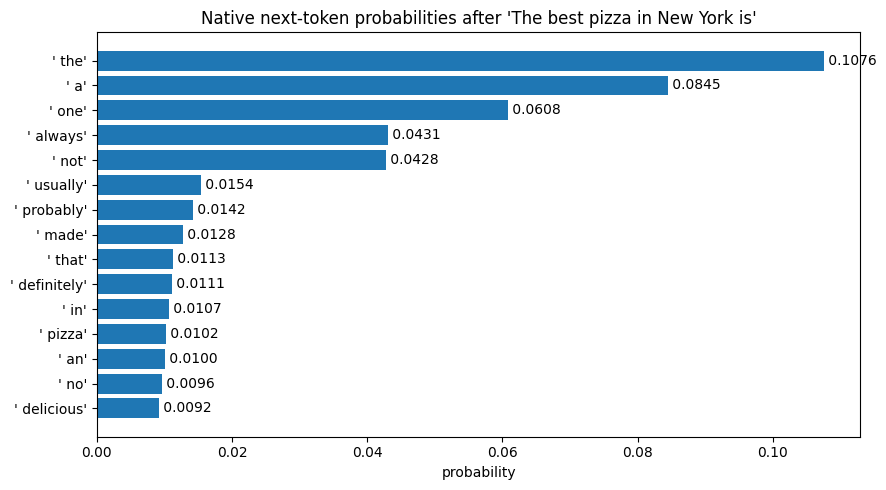

native next-token distribution
token                probability
----------------------------------
' the'               0.1076
' a'                 0.0845
' one'               0.0608
' always'            0.0431
' not'               0.0428
' usually'           0.0154
' probably'          0.0142
' made'              0.0128
' that'              0.0113
' definitely'        0.0111
' in'                0.0107
' pizza'             0.0102
' an'                0.0100
' no'                0.0096
' delicious'         0.0092


In [18]:
next_token_prompt = "The best pizza in New York is"

rows = next_token_rows(
    model_artifact,
    next_token_prompt,
    temperature=1.0,
    top_k=None,
    top_p=None,
    n=15,
)

labels = [token_text for token_text, _ in rows]
probs = [prob for _, prob in rows]

fig, ax = plt.subplots(figsize=(9, 5))
y = list(range(len(rows)))
ax.barh(y, probs)
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set_xlabel("probability")
ax.set_title(f"Native next-token probabilities after {next_token_prompt!r}")
for index, prob in enumerate(probs):
    ax.text(prob, index, f" {prob:.4f}", va="center")
plt.tight_layout()
plt.show()

print("native next-token distribution")
print("token                probability")
print("-" * 34)
for token_text, prob in rows:
    print(f"{token_text:<20} {prob:.4f}")

In [ ]:
"Question: Does your model have one dominant next token here, or is the mass spread across many plausible tokens? How would that affect random sampling?"
"Answer: "

## Exercise 4 - Quantify looping with type-token ratio

The type-token ratio is crude but useful: distinct generated token IDs divided by total generated token IDs. Greedy or repetitive output usually has a low ratio.

greedy         type-token ratio: 0.662
penalty=1.0    type-token ratio: 0.713
penalty=1.1    type-token ratio: 0.825
penalty=1.3    type-token ratio: 0.947


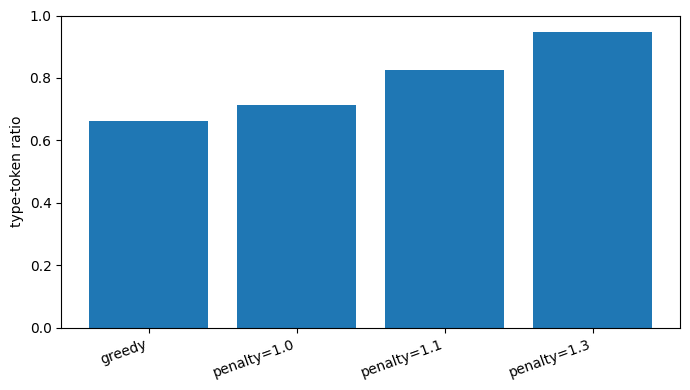

In [10]:
prompt_ids = encode_prompt(model_artifact, prompt)
penalty_settings = [
    ("greedy", dict(temperature=0.0, top_p=None, repetition_penalty=1.0)),
    ("penalty=1.0", dict(temperature=0.7, top_p=0.9, repetition_penalty=1.0)),
    ("penalty=1.1", dict(temperature=0.7, top_p=0.9, repetition_penalty=1.1)),
    ("penalty=1.3", dict(temperature=0.7, top_p=0.9, repetition_penalty=1.3)),
]

ratios = []
for label, kwargs in penalty_settings:
    ids = sample_ids(model_artifact, prompt, max_new_tokens=DEFAULT_MAX_NEW_TOKENS, seed=2, **kwargs)
    continuation = ids[len(prompt_ids):]
    ratio = type_token_ratio(continuation)
    ratios.append((label, ratio))
    print(f"{label:<14} type-token ratio: {ratio:.3f}")

plt.figure(figsize=(7, 4))
plt.bar([label for label, _ in ratios], [ratio for _, ratio in ratios])
plt.ylabel("type-token ratio")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
"Question: Does repetition penalty improve the type-token ratio for your model? Does the output also read better, or just less repetitive?"
"Answer: "

## Exercise 5 - Greedy two ways

`temperature=0.0` is the explicit greedy path. `top_k=1` leaves only one possible sampled token. These should match exactly.

In [ ]:
greedy_ids = sample_ids(
    model_artifact,
    prompt,
    max_new_tokens=DEFAULT_MAX_NEW_TOKENS,
    temperature=0.0,
    top_k=None,
    top_p=None,
    repetition_penalty=1.0,
    seed=123,
)
topk1_ids = sample_ids(
    model_artifact,
    prompt,
    max_new_tokens=DEFAULT_MAX_NEW_TOKENS,
    temperature=1.0,
    top_k=1,
    top_p=None,
    repetition_penalty=1.0,
    seed=999,
)

assert torch.equal(greedy_ids, topk1_ids)
print("greedy and top_k=1 produced identical token IDs")
print_sample("greedy sample", decode_ids(model_artifact, greedy_ids))

In [ ]:
"Question: Why does top_k=1 match greedy even though one path uses multinomial sampling?"
"Answer: "

## Exercise 6 - Small playground

The function below gives you an interactive-style playground without forcing an infinite input loop during Run All. Change `settings`, call `playground("your prompt")`, and compare outputs.

In [19]:
settings = {
    "max_new_tokens": DEFAULT_MAX_NEW_TOKENS,
    "temperature": 0.25,
    "top_k": None,
    "top_p": 0.2,
    "repetition_penalty": 1.1,
    "seed": 0,
}


def playground(user_prompt: str, **overrides) -> str:
    args = {**settings, **overrides}
    return sample_and_show(f"prompt={user_prompt!r} | {args}", user_prompt, **args)


_ = playground("The best pizza in New York is")

In [ ]:
"Question: Try at least three prompts. What kinds of prompts does your artifact handle best? What reliably breaks it?"
"Answer: "

## Optional extension - forbid a few token IDs

This is a small preview of logit biasing. Pick token IDs, set their logits to `-inf`, and they cannot be sampled. Real systems use this same idea for constrained decoding and content controls.

In [ ]:
def generate_with_forbidden_ids(
    prompt: str,
    forbid_ids: list[int],
    *,
    max_new_tokens: int = DEFAULT_MAX_NEW_TOKENS,
    temperature: float = 0.8,
    top_p: float | None = 0.9,
    seed: int = 0,
) -> torch.Tensor:
    full_ids = encode_prompt(model_artifact, prompt).detach().cpu().clone()
    generator = torch.Generator().manual_seed(seed)
    forbidden = torch.tensor(forbid_ids, dtype=torch.long)
    for _ in range(max_new_tokens):
        ctx = full_ids[-model.max_seq_len:].to(model.device).unsqueeze(0)
        with torch.no_grad():
            logits = model(ctx)[:, -1, :].cpu()
        logits[:, forbidden] = float("-inf")
        logits = apply_temperature(logits, temperature)
        if top_p is not None:
            logits = top_p_filter(logits, top_p)
        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1, generator=generator).squeeze(-1)
        full_ids = torch.cat([full_ids, next_id], dim=0)
        stop_id = eos_id(model_artifact)
        if stop_id is not None and next_id.item() == stop_id:
            break
    return full_ids

# Pick a few visible tokens from the next-token table to forbid.
rows = next_token_rows(model_artifact, prompt, temperature=0.8, top_p=0.9, n=5)
print("Use the next-token table above to choose forbid_ids if you want to experiment.")
print("Example rows:", rows)

In [ ]:
"Question: If you tried forbidden IDs, which tokens did you forbid and how did the continuation change?"
"Answer: "